# Jacobian Lens: sparse decomposition in J-space

`JacobianLens.decompose` expresses an activation using a sparse, nonnegative combination of J-lens vectors $v_t = J_ℓ^T W_U[:, t]$. This notebook studies the resulting geometry, variance profile, control-calibrated occupancy, relationship to ranked readouts, solver trade-offs, and causal relevance of the selected span.

This is an **open-weight methodological replication** of analyses from Gurnee et al. (2026), [*Verbalizable Representations Form a Global Workspace in Language Models*](https://transformer-circuits.pub/2026/workspace/index.html). The paper's quantitative effects were measured on closed Anthropic models, so their values are context rather than targets here. Null, contradictory, and missing results remain visible.

The separate [Jacobian Lens demo](https://github.com/TransformerLensOrg/TransformerLens/blob/dev/demos/Jacobian_Lens_Demo.ipynb) covers ranked readout, country-coordinate swaps, steering, and fitting. This notebook does not repeat those walkthroughs.

In [ ]:
# NBVAL_IGNORE_OUTPUT
import gc
import os
import random
import time
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import torch

from huggingface_hub.utils import logging as hf_hub_logging
from IPython.display import Markdown, display
from transformers.utils import logging as hf_logging

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
hf_hub_logging.set_verbosity_error()
hf_logging.set_verbosity_error()
hf_logging.disable_progress_bar()

from transformer_lens.model_bridge import TransformerBridge
from transformer_lens.tools.analysis import JacobianLens

SEED = 7
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DTYPE = torch.float32
MODEL_ID = "gpt2"
LENS_NAME = "gpt2-small"
LENS_REVISION = "0731326edff4ae730ffc5356fe1a4728c748b3a6"
RUN_FULL_ANALYSIS = os.getenv("RUN_FULL_ANALYSIS", "true").lower() == "true"
K = 16
PROFILE_LAYERS = (1, 4, 7, 10)
MAX_ATOMS = 25
NUM_OCCUPANCY_CONTROLS = 32 if RUN_FULL_ANALYSIS else 4
NUM_RANDOM_SPANS = 16 if RUN_FULL_ANALYSIS else 4
NUM_RANDOM_CANDIDATE_SPANS = 128 if RUN_FULL_ANALYSIS else 32
MAX_CAUSAL_VALID_TRIALS = None if RUN_FULL_ANALYSIS else 8

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

model = TransformerBridge.boot_transformers(MODEL_ID, device=DEVICE, dtype=DTYPE)
model.eval()
lens = JacobianLens.from_pretrained(LENS_NAME, model=model, revision=LENS_REVISION)
model_revision = getattr(model.original_model.config, "_commit_hash", None)
print({
    "model": MODEL_ID,
    "model_revision": model_revision,
    "lens": LENS_NAME,
    "lens_revision": LENS_REVISION,
    "lens_metadata": lens.metadata,
    "torch_version": version("torch"),
    "transformers_version": version("transformers"),
    "transformer_lens_version": version("transformer-lens"),
    "device": DEVICE,
    "dtype": str(DTYPE),
    "seed": SEED,
    "full_analysis": RUN_FULL_ANALYSIS,
    "d_model": lens.d_model,
    "layers": PROFILE_LAYERS,
    "k": K,
    "max_atoms": MAX_ATOMS,
    "occupancy_controls": NUM_OCCUPANCY_CONTROLS,
    "random_span_candidates": NUM_RANDOM_CANDIDATE_SPANS,
    "matched_random_spans": NUM_RANDOM_SPANS,
})

{'model': 'gpt2', 'model_revision': '607a30d783dfa663caf39e06633721c8d4cfcd7e', 'lens': 'gpt2-small', 'lens_revision': '0731326edff4ae730ffc5356fe1a4728c748b3a6', 'lens_metadata': {}, 'torch_version': '2.13.0', 'transformers_version': '5.15.1', 'transformer_lens_version': '0.0.0', 'device': 'cuda', 'dtype': 'torch.float32', 'seed': 7, 'full_analysis': True, 'd_model': 768, 'layers': (1, 4, 7, 10), 'k': 16, 'max_atoms': 25, 'occupancy_controls': 32, 'random_span_candidates': 128, 'matched_random_spans': 16}


### Execution tiers

The saved notebook uses the full tier (`RUN_FULL_ANALYSIS = True`): 32 occupancy controls, 16 exactly removed-norm-matched selected/random intervention pairs chosen from 128 random candidates per causal trial, and every baseline-valid candidate. Set it to `False` for a faster exploratory run with 4 occupancy controls, 4 matched pairs selected from 32 candidates, and at most 8 valid trials.

## Decomposition geometry

The pursuit selects up to `k` dictionary atoms. `selected_support` records every selected atom, while `support` contains the subset with positive final coefficients. The nonnegative `reconstruction` and the orthogonal selected-span projection `j_space_component` can differ; `non_j_space_component` is the residual from that orthogonal projection.

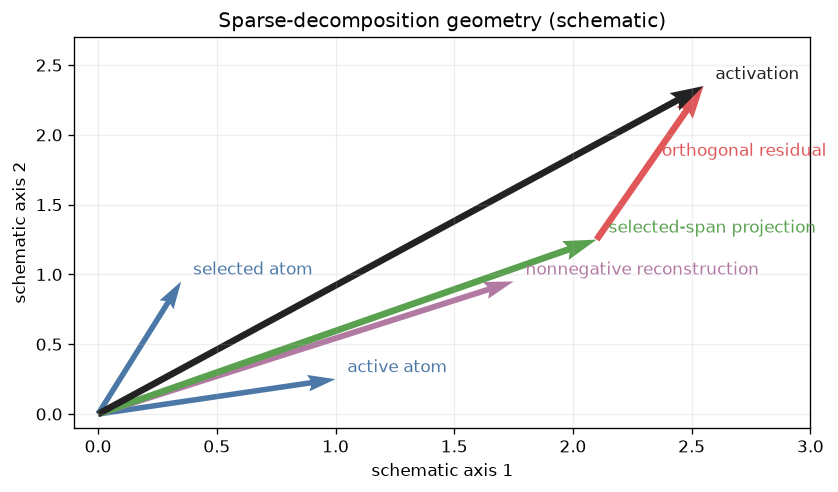

In [2]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(7.2, 4.2), dpi=120)
origin = np.array([0.0, 0.0])
atom_a = np.array([1.0, 0.25])
atom_b = np.array([0.35, 0.95])
reconstruction = np.array([1.75, 0.95])
j_component = np.array([2.1, 1.25])
residual = np.array([0.45, 1.1])
activation = j_component + residual

for atom, label in [(atom_a, "active atom"), (atom_b, "selected atom")]:
    ax.quiver(*origin, *atom, angles="xy", scale_units="xy", scale=1, color="#4C78A8")
    ax.text(*(atom + 0.05), label, color="#4C78A8")
ax.quiver(*origin, *reconstruction, angles="xy", scale_units="xy", scale=1, color="#B279A2", width=0.008)
ax.quiver(*origin, *j_component, angles="xy", scale_units="xy", scale=1, color="#59A14F", width=0.009)
ax.quiver(*j_component, *residual, angles="xy", scale_units="xy", scale=1, color="#E15759", width=0.009)
ax.quiver(*origin, *activation, angles="xy", scale_units="xy", scale=1, color="#222222", width=0.009)
ax.text(*(reconstruction + 0.05), "nonnegative reconstruction", color="#B279A2")
ax.text(*(j_component + 0.05), "selected-span projection", color="#59A14F")
ax.text(*(j_component + residual / 2 + 0.05), "orthogonal residual", color="#E15759")
ax.text(*(activation + 0.05), "activation", color="#222222")
ax.set(xlim=(-0.1, 3.0), ylim=(-0.1, 2.7), xlabel="schematic axis 1", ylabel="schematic axis 2")
ax.set_title("Sparse-decomposition geometry (schematic)")
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

**Geometry caption.** This schematic distinguishes selected atoms, positive-coordinate atoms, the nonnegative reconstruction, and the orthogonal selected-span split. **Figure description:** blue arrows are dictionary atoms, the purple arrow is their nonnegative reconstruction, the green arrow is the selected-span projection, and the red segment is the residual to the black activation vector. It is explanatory rather than a measured model result.

## Experiment A — decode local sparse coordinates

**Question.** What local coordinates appear for contrasting prompts? We decompose four final-position activations at one intermediate layer. `selected_support` records all pursuit selections; active `support` aligns with the positive `coordinates`. Coordinates are local nonnegative coefficients, not probabilities, logits, or causal effects.

In [3]:
# NBVAL_IGNORE_OUTPUT
COORDINATE_PROMPTS = (
    "The Eiffel Tower is in the city of",
    "The largest planet in the Solar System is",
    "A triangle has three sides and a square has",
    "After the storm cleared, the night sky was",
)
COORDINATE_LAYER = 6
coordinate_results = {}
for prompt in COORDINATE_PROMPTS:
    decomposition = lens.decompose(
        model, prompt, layer=COORDINATE_LAYER, position=-1, k=K
    )
    coordinate_results[prompt] = decomposition
    active_tokens = [model.to_string(int(token_id)) for token_id in decomposition.support]
    print(f"\n{prompt!r}")
    print(
        f"requested k={K}; selected={len(decomposition.selected_support)}; "
        f"active={len(decomposition.support)}"
    )
    print("selected_support:", decomposition.selected_support.tolist())
    for token, coordinate in zip(active_tokens, decomposition.coordinates.tolist()):
        print(f"  {coordinate: .6e}  {token!r}")


'The Eiffel Tower is in the city of'
requested k=16; selected=11; active=10
selected_support: [810, 3240, 262, 3207, 2995, 9882, 17589, 1781, 34321, 29913, 16648]
   6.480888e-01  ' town'
   4.822368e-01  ' the'
   2.216958e-01  ' thous'
   6.094690e-02  ' events'
   1.219469e-01  ' neighb'
   5.182938e-02  ' Ing'
   6.140878e-02  ' course'
   5.437329e-02  ' Herz'
   1.694903e-02  ' Perth'
   1.030920e-02  ' fortun'

'The largest planet in the Solar System is'
requested k=16; selected=10; active=9
selected_support: [1682, 783, 21094, 41559, 262, 30185, 17773, 2192, 11950, 17508]
   2.112072e-01  ' now'
   1.143229e-01  ' Venus'
   2.359303e-01  ' Guinness'
   4.815359e-01  ' the'
   2.376936e-01  ' Antarctica'
   7.619075e-02  ' skelet'
   3.854924e-02  ' probably'
   3.773420e-02  ' Universe'
   1.964713e-02  ' Apollo'

'A triangle has three sides and a square has'
requested k=16; selected=7; active=7
selected_support: [734, 24438, 198, 5144, 6906, 13, 35901]
   6.571675e-01  ' two'


'After the storm cleared, the night sky was'
requested k=16; selected=12; active=12
selected_support: [618, 6729, 9020, 991, 262, 44030, 6193, 15038, 757, 47673, 11727, 6451]
   1.794345e-01  ' when'
   2.612148e-01  ' snow'
   1.583038e-01  ' arrang'
   3.395279e-02  ' still'
   3.820599e-01  ' the'
   1.164848e-01  ' molten'
   1.459112e-01  ' weather'
   4.302468e-02  ' seiz'
   6.076093e-02  ' again'
   2.964824e-02  ' beck'
   2.648926e-02  ' helicop'
   1.933134e-02  ' suddenly'


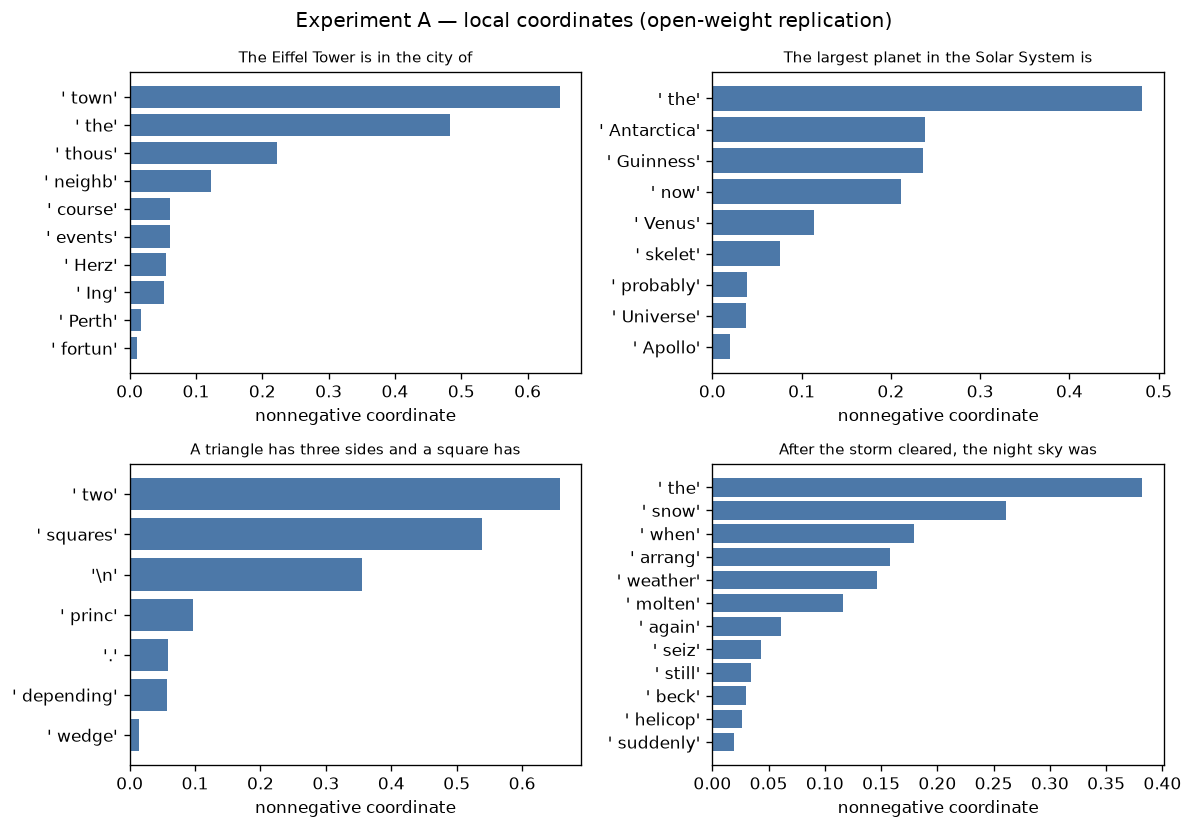

In [4]:
# NBVAL_IGNORE_OUTPUT
fig, axes = plt.subplots(2, 2, figsize=(10, 7), dpi=120)
for ax, (prompt, decomposition) in zip(axes.flat, coordinate_results.items()):
    tokens = [model.to_string(int(token_id)) for token_id in decomposition.support]
    order = torch.argsort(decomposition.coordinates).tolist()
    values = decomposition.coordinates[order].cpu().numpy()
    labels = [repr(tokens[index]) for index in order]
    ax.barh(labels, values, color="#4C78A8")
    ax.set_title(prompt, fontsize=9)
    ax.set_xlabel("nonnegative coordinate")
fig.suptitle("Experiment A — local coordinates (open-weight replication)")
plt.tight_layout()
plt.show()

**Experiment A caption.** Four GPT-2 final-position activations are decomposed at layer 6 with the declared `k`. **Figure description:** four horizontal bar charts show active token directions and their nonnegative coefficients; longer bars indicate larger local reconstruction coefficients. Token strings preserve whitespace artifacts. The plots do not establish a ranked or causal interpretation.

## Three quantities that must remain separate

Experiment B measures an absolute projection fraction. Experiment C estimates an occupancy step using separation from random controls. Their difference curve is a control-relative excess, not another absolute variance estimate.

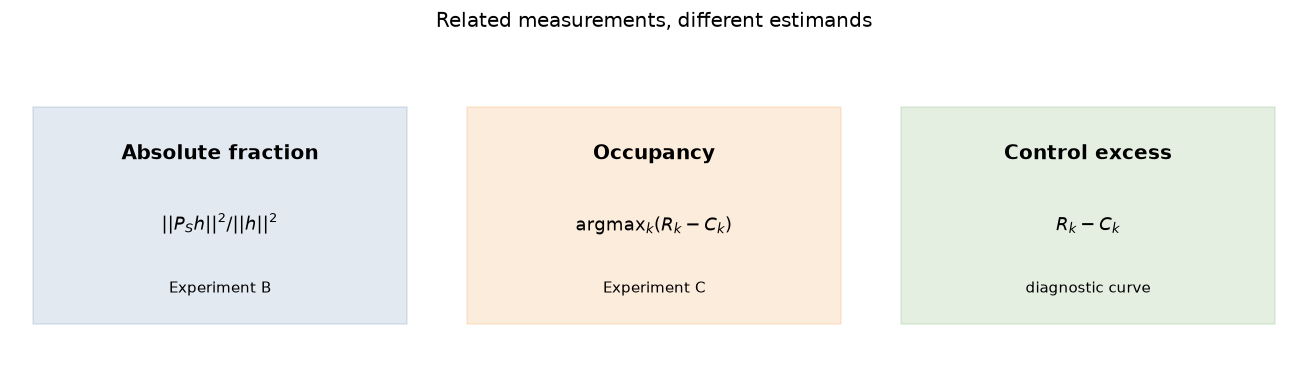

In [5]:
# NBVAL_IGNORE_OUTPUT
fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), dpi=120)
panels = (
    ("Absolute fraction", "$||P_S h||^2 / ||h||^2$", "Experiment B", "#4C78A8"),
    ("Occupancy", r"$\mathrm{argmax}_k (R_k-C_k)$", "Experiment C", "#F28E2B"),
    ("Control excess", "$R_k-C_k$", "diagnostic curve", "#59A14F"),
)
for ax, (title, formula, subtitle, color) in zip(axes, panels):
    ax.axis("off")
    ax.add_patch(plt.Rectangle((0.05, 0.15), 0.9, 0.7, color=color, alpha=0.16))
    ax.text(0.5, 0.68, title, ha="center", fontsize=12, weight="bold")
    ax.text(0.5, 0.45, formula, ha="center", fontsize=11)
    ax.text(0.5, 0.25, subtitle, ha="center", fontsize=9)
fig.suptitle("Related measurements, different estimands")
plt.tight_layout()
plt.show()

**Metric caption.** Absolute selected-span variance, control-calibrated occupancy, and real-minus-control excess answer different questions and are never compared to the same reference line. **Figure description:** three side-by-side boxes display the formula and experiment associated with each estimand.

## Experiment B — absolute fraction of activation variance

**Question.** Across a small prompt corpus, how much activation energy lies in each decomposition-selected span? `fraction_of_variance` computes the orthogonal projection fraction at explicit positions and reports both the median position and pooled ratio.

In [6]:
# NBVAL_IGNORE_OUTPUT
PROFILE_PROMPTS = (
    "Paris grew around islands in the Seine and became a center of art, politics, science, commerce, and education across Europe.",
    "Astronomers compare planets by mass, orbit, atmosphere, temperature, moons, and composition when describing the structure of the Solar System.",
    "During photosynthesis, plants use light energy to transform water and carbon dioxide into chemical energy while releasing oxygen.",
    "A computer program transforms input data through a sequence of instructions, stores intermediate state in memory, and returns an output.",
)
PROFILE_POSITIONS = (-9, -5, -1)
variance_profile = lens.fraction_of_variance(
    model,
    PROFILE_PROMPTS,
    layers=PROFILE_LAYERS,
    k=K,
    positions=PROFILE_POSITIONS,
)
for layer in variance_profile.layers:
    values = variance_profile.per_position[layer]
    print(
        f"layer={layer:2d} samples={values.numel():2d} "
        f"median={variance_profile.median[layer]:.3%} "
        f"pooled={variance_profile.pooled[layer]:.3%}"
    )

layer= 1 samples=12 median=2.799% pooled=4.855%
layer= 4 samples=12 median=1.937% pooled=3.227%
layer= 7 samples=12 median=1.978% pooled=2.611%
layer=10 samples=12 median=1.967% pooled=2.107%


The 10% value reported for closed Anthropic models is context, not a target for GPT-2. The plotted samples are a small, declared corpus rather than a population estimate.

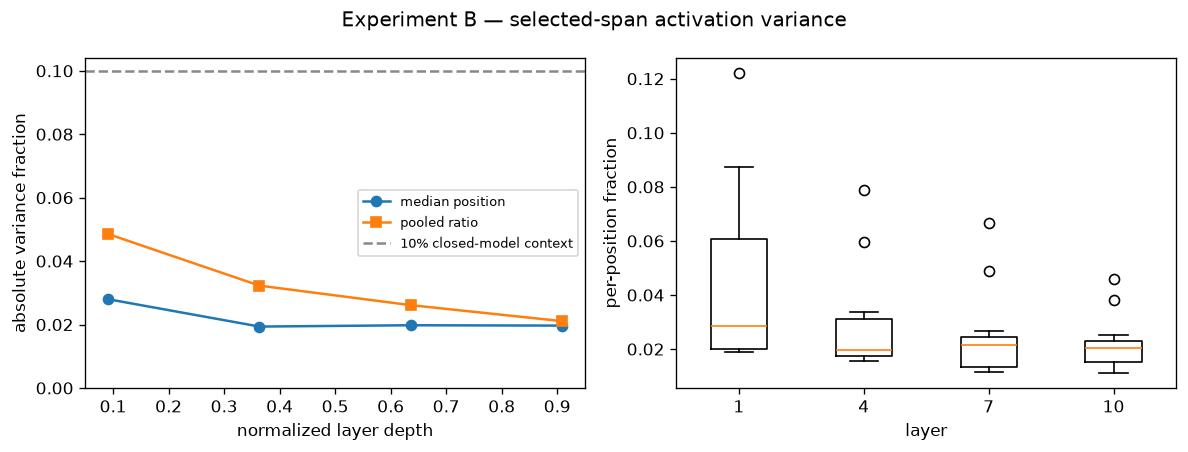

In [7]:
# NBVAL_IGNORE_OUTPUT
layers = variance_profile.layers
depth = np.array(layers) / (model.cfg.n_layers - 1)
median_fraction = np.array([variance_profile.median[layer] for layer in layers])
pooled_fraction = np.array([variance_profile.pooled[layer] for layer in layers])
fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), dpi=120)
axes[0].plot(depth, median_fraction, marker="o", label="median position")
axes[0].plot(depth, pooled_fraction, marker="s", label="pooled ratio")
axes[0].axhline(0.10, color="#888888", linestyle="--", label="10% closed-model context")
axes[0].set(xlabel="normalized layer depth", ylabel="absolute variance fraction", ylim=(0, None))
axes[0].legend(fontsize=8)
per_layer = [variance_profile.per_position[layer].numpy() for layer in layers]
axes[1].boxplot(per_layer, tick_labels=[str(layer) for layer in layers], showfliers=True)
axes[1].set(xlabel="layer", ylabel="per-position fraction")
fig.suptitle("Experiment B — selected-span activation variance")
plt.tight_layout()
plt.show()

**Experiment B caption.** Over four prompts and three explicit positions per prompt, GPT-2 median fractions are about 1.9–2.8% and pooled fractions about 2.1–4.9%. **Figure description:** the left panel plots median and pooled fractions by normalized layer depth against a dashed contextual 10% line; the right panel shows per-position box plots at each layer. The dashed line is closed-model context only, not an occupancy threshold or expected GPT-2 value.

## Experiment C — occupancy against random controls

**Question.** At which pursuit step is cumulative captured variance for the real dictionary maximally separated from averaged random unit-norm dictionaries? This is the API's occupancy definition—not active coefficient count and not an eyeballed elbow.

In [8]:
# NBVAL_IGNORE_OUTPUT
OCCUPANCY_PROMPTS = COORDINATE_PROMPTS[: 2 if RUN_FULL_ANALYSIS else 1]
occupancy_trials = []
for prompt_index, prompt in enumerate(OCCUPANCY_PROMPTS):
    for layer in PROFILE_LAYERS:
        estimate = lens.occupancy(
            model,
            prompt,
            layer=layer,
            position=-1,
            max_atoms=MAX_ATOMS,
            num_control_dictionaries=NUM_OCCUPANCY_CONTROLS,
            seed=SEED + 100 * prompt_index + layer,
        )
        occupancy_trials.append({
            "prompt_index": prompt_index,
            "layer": layer,
            "occupancy": estimate.occupancy,
            "real_marginal": estimate.marginal_captured_variance.numpy(),
            "control_marginal": estimate.control_captured_variance.numpy(),
        })
        print(f"prompt={prompt_index} layer={layer:2d} occupancy={estimate.occupancy}")

prompt=0 layer= 1 occupancy=1


prompt=0 layer= 4 occupancy=1


prompt=0 layer= 7 occupancy=1


prompt=0 layer=10 occupancy=1


prompt=1 layer= 1 occupancy=1


prompt=1 layer= 4 occupancy=1


prompt=1 layer= 7 occupancy=1


prompt=1 layer=10 occupancy=1


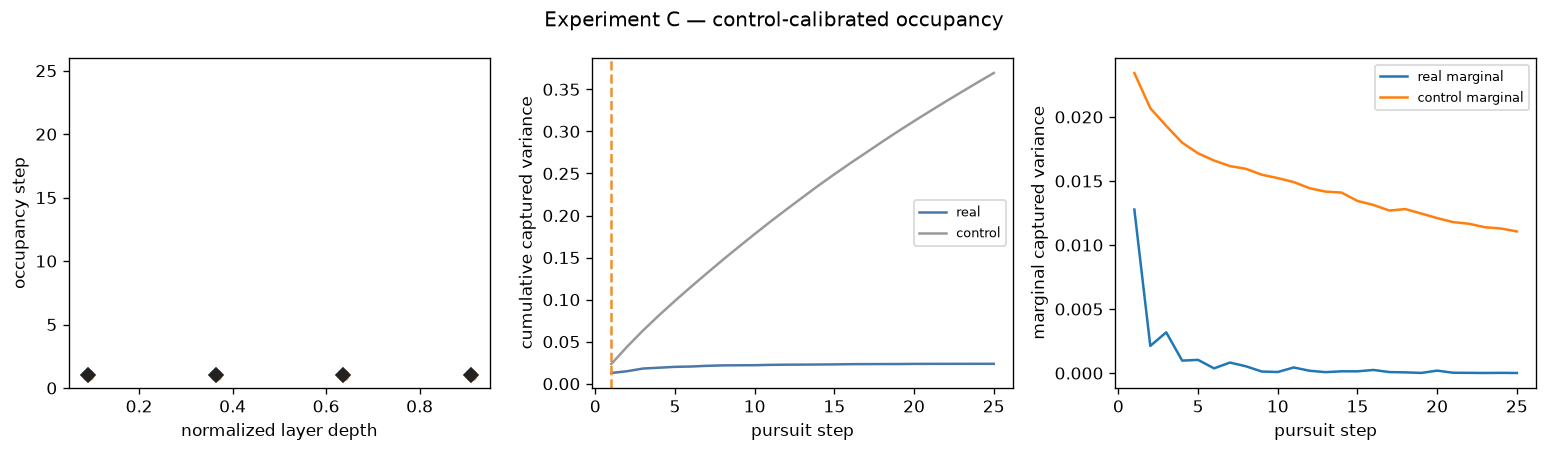

In [9]:
# NBVAL_IGNORE_OUTPUT
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), dpi=120)
for row in occupancy_trials:
    axes[0].scatter(row["layer"] / (model.cfg.n_layers - 1), row["occupancy"], color="#F28E2B", alpha=0.75)
for layer in PROFILE_LAYERS:
    values = [row["occupancy"] for row in occupancy_trials if row["layer"] == layer]
    axes[0].plot(layer / (model.cfg.n_layers - 1), np.median(values), marker="D", color="#222222")
axes[0].set(xlabel="normalized layer depth", ylabel="occupancy step", ylim=(0, MAX_ATOMS + 1))
representative = occupancy_trials[len(occupancy_trials) // 2]
steps = np.arange(1, MAX_ATOMS + 1)
real_cumulative = np.cumsum(representative["real_marginal"])
control_cumulative = np.cumsum(representative["control_marginal"])
axes[1].plot(steps, real_cumulative, label="real", color="#4C78A8")
axes[1].plot(steps, control_cumulative, label="control", color="#999999")
axes[1].axvline(representative["occupancy"], color="#F28E2B", linestyle="--")
axes[1].set(xlabel="pursuit step", ylabel="cumulative captured variance")
axes[1].legend(fontsize=8)
axes[2].plot(steps, representative["real_marginal"], label="real marginal")
axes[2].plot(steps, representative["control_marginal"], label="control marginal")
axes[2].set(xlabel="pursuit step", ylabel="marginal captured variance")
axes[2].legend(fontsize=8)
fig.suptitle("Experiment C — control-calibrated occupancy")
plt.tight_layout()
plt.show()

**Experiment C caption.** The saved full-tier run uses two prompts and 32 controls per layer; the generated result summary below reports the canonical occupancy range. **Figure description:** the left panel shows occupancy points and layer medians, the center compares representative cumulative real/control capture, and the right compares their marginal gains; a vertical marker identifies maximum separation. Occupancy is the maximum-separation step, not active coefficient count or an eyeballed elbow.

## Experiment D — sparse support versus ranked readouts

**Question.** Is active sparse support equivalent to either J-lens or ordinary logit-lens top-k rankings? We compare equal-size sets with Jaccard overlap; the existing Jacobian Lens demo remains the full readout tutorial.

In [10]:
# NBVAL_IGNORE_OUTPUT
def jaccard(left, right):
    left, right = set(left), set(right)
    return len(left & right) / len(left | right) if left or right else float("nan")

overlap_trials = []
for prompt_index, prompt in enumerate(COORDINATE_PROMPTS):
    jacobian_readout = lens.readout(
        model, prompt, layers=PROFILE_LAYERS, positions=[-1], use_jacobian=True, top_k=K
    )
    logit_readout = lens.readout(
        model, prompt, layers=PROFILE_LAYERS, positions=[-1], use_jacobian=False, top_k=K
    )
    for layer in PROFILE_LAYERS:
        decomposition = lens.decompose(model, prompt, layer=layer, position=-1, k=K)
        support = decomposition.support.tolist()
        active_count = len(support)
        jacobian_ranked = jacobian_readout.lens_topk_indices[layer][0, :active_count].tolist()
        logit_ranked = logit_readout.lens_topk_indices[layer][0, :active_count].tolist()
        overlap_trials.append({
            "prompt_index": prompt_index,
            "layer": layer,
            "active_count": active_count,
            "jacobian_jaccard": jaccard(support, jacobian_ranked),
            "logit_jaccard": jaccard(support, logit_ranked),
        })
for row in overlap_trials:
    print(
        f"prompt={row['prompt_index']} layer={row['layer']:2d} active={row['active_count']:2d} "
        f"J={row['jacobian_jaccard']:.3f} logit={row['logit_jaccard']:.3f}"
    )

prompt=0 layer= 1 active=14 J=0.077 logit=0.037
prompt=0 layer= 4 active= 9 J=0.200 logit=0.125
prompt=0 layer= 7 active= 9 J=0.200 logit=0.059
prompt=0 layer=10 active=12 J=0.263 logit=0.600
prompt=1 layer= 1 active=15 J=0.034 logit=0.071
prompt=1 layer= 4 active= 8 J=0.067 logit=0.067
prompt=1 layer= 7 active= 9 J=0.125 logit=0.200
prompt=1 layer=10 active= 5 J=0.667 logit=1.000
prompt=2 layer= 1 active=14 J=0.077 logit=0.000
prompt=2 layer= 4 active=10 J=0.053 logit=0.053
prompt=2 layer= 7 active=10 J=0.250 logit=0.176
prompt=2 layer=10 active= 5 J=0.111 logit=0.111
prompt=3 layer= 1 active=16 J=0.032 logit=0.000
prompt=3 layer= 4 active= 7 J=0.077 logit=0.000
prompt=3 layer= 7 active=10 J=0.053 logit=0.053
prompt=3 layer=10 active=11 J=0.692 logit=0.692


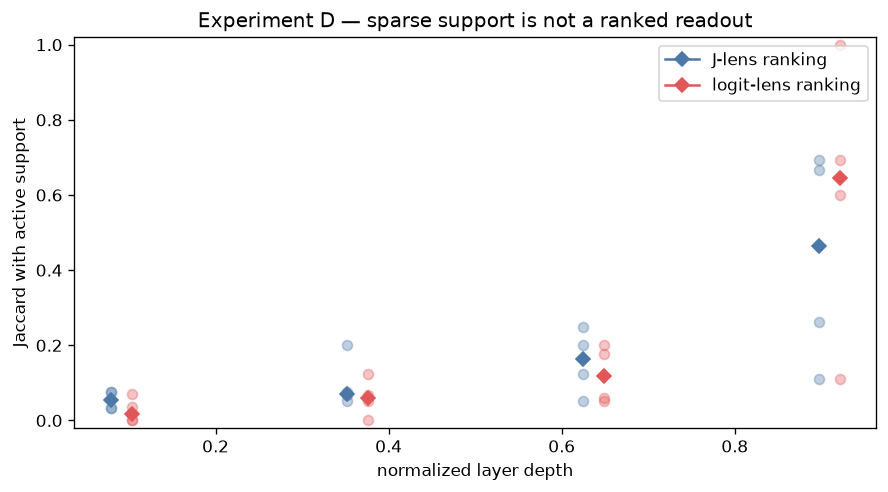

In [11]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(7.5, 4.2), dpi=120)
for offset, key, label, color in [(-0.012, "jacobian_jaccard", "J-lens ranking", "#4C78A8"), (0.012, "logit_jaccard", "logit-lens ranking", "#E15759")]:
    for layer in PROFILE_LAYERS:
        values = np.array([row[key] for row in overlap_trials if row["layer"] == layer])
        x = layer / (model.cfg.n_layers - 1) + offset
        ax.scatter(np.full(values.shape, x), values, color=color, alpha=0.35)
        ax.plot(x, np.nanmedian(values), marker="D", color=color)
ax.plot([], [], color="#4C78A8", marker="D", label="J-lens ranking")
ax.plot([], [], color="#E15759", marker="D", label="logit-lens ranking")
ax.set(xlabel="normalized layer depth", ylabel="Jaccard with active support", ylim=(-0.02, 1.02))
ax.legend()
ax.set_title("Experiment D — sparse support is not a ranked readout")
plt.tight_layout()
plt.show()

**Experiment D caption.** Both comparisons use a ranked set whose size equals that trial's active support. **Figure description:** paired point clouds at four normalized depths compare Jaccard overlap with J-lens and logit-lens rankings; diamonds mark layer medians. Sparse support is neither assumed disjoint from nor equivalent to ranked readouts.

## Experiment E — NNOMP versus gradient pursuit

**Question.** How do exact nonnegative active-set re-solving and directional gradient pursuit trade reconstruction quality, support, and warm-cache runtime? They share a greedy selection rule, but coefficient residuals can change later selections.

In [12]:
# NBVAL_IGNORE_OUTPUT
ALGORITHM_LAYER = 6
hook_name = f"blocks.{ALGORITHM_LAYER}.hook_out"
algorithm_activations = []
for prompt in COORDINATE_PROMPTS:
    tokens = model.to_tokens(prompt)
    _, cache = model.run_with_cache(tokens, names_filter=[hook_name])
    algorithm_activations.append(cache[hook_name][0, -1].detach())
_ = lens.lens_vector_dictionary(model, ALGORITHM_LAYER)

ALGORITHMS = ("nonnegative_orthogonal_matching_pursuit", "gradient_pursuit")
algorithm_trials = []
for prompt_index, activation in enumerate(algorithm_activations):
    trial_results = {}
    for algorithm in ALGORITHMS:
        timings = []
        decomposition = None
        for _ in range(3):
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            started = time.perf_counter()
            decomposition = lens.decompose(
                model, activation, layer=ALGORITHM_LAYER, k=K, algorithm=algorithm
            )
            if DEVICE == "cuda":
                torch.cuda.synchronize()
            timings.append(1000 * (time.perf_counter() - started))
        activation_cpu = activation.float().cpu()
        reconstruction_cpu = decomposition.reconstruction.float().cpu()
        error = (activation_cpu - reconstruction_cpu).norm() / activation_cpu.norm()
        trial_results[algorithm] = decomposition
        algorithm_trials.append({
            "prompt_index": prompt_index,
            "algorithm": algorithm,
            "runtime_ms": float(np.median(timings)),
            "relative_error": float(error),
            "active_count": len(decomposition.support),
            "selected_count": len(decomposition.selected_support),
        })
    left = trial_results[ALGORITHMS[0]].support.tolist()
    right = trial_results[ALGORITHMS[1]].support.tolist()
    support_overlap = jaccard(left, right)
    for row in algorithm_trials[-2:]:
        row["support_jaccard"] = support_overlap
for row in algorithm_trials:
    print(row)

{'prompt_index': 0, 'algorithm': 'nonnegative_orthogonal_matching_pursuit', 'runtime_ms': 114.34537498280406, 'relative_error': 0.9942731857299805, 'active_count': 10, 'selected_count': 11, 'support_jaccard': 0.7272727272727273}
{'prompt_index': 0, 'algorithm': 'gradient_pursuit', 'runtime_ms': 10.658037033863366, 'relative_error': 0.9947514533996582, 'active_count': 9, 'selected_count': 11, 'support_jaccard': 0.7272727272727273}
{'prompt_index': 1, 'algorithm': 'nonnegative_orthogonal_matching_pursuit', 'runtime_ms': 95.20069102291018, 'relative_error': 0.9961159229278564, 'active_count': 9, 'selected_count': 10, 'support_jaccard': 0.46153846153846156}
{'prompt_index': 1, 'algorithm': 'gradient_pursuit', 'runtime_ms': 12.326687923632562, 'relative_error': 0.996773362159729, 'active_count': 10, 'selected_count': 13, 'support_jaccard': 0.46153846153846156}
{'prompt_index': 2, 'algorithm': 'nonnegative_orthogonal_matching_pursuit', 'runtime_ms': 55.25528802536428, 'relative_error': 0.992

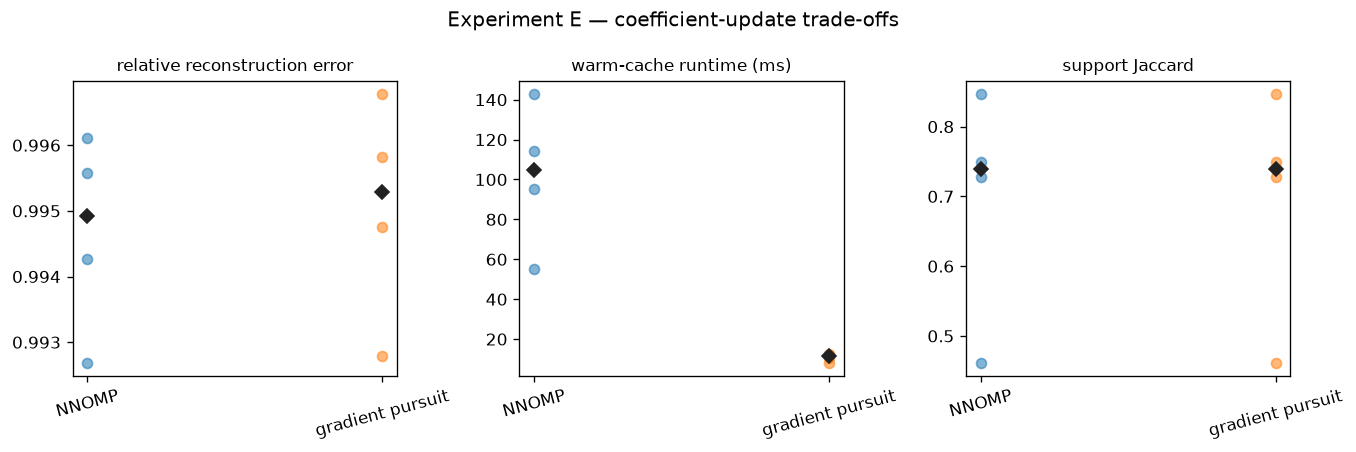

In [13]:
# NBVAL_IGNORE_OUTPUT
short_names = {ALGORITHMS[0]: "NNOMP", ALGORITHMS[1]: "gradient pursuit"}
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.8), dpi=120)
for axis, metric, title in zip(axes, ["relative_error", "runtime_ms", "support_jaccard"], ["relative reconstruction error", "warm-cache runtime (ms)", "support Jaccard"]):
    for index, algorithm in enumerate(ALGORITHMS):
        values = [row[metric] for row in algorithm_trials if row["algorithm"] == algorithm]
        axis.scatter(np.full(len(values), index), values, alpha=0.55)
        axis.plot(index, np.median(values), marker="D", color="#222222")
    axis.set_xticks(range(len(ALGORITHMS)), [short_names[item] for item in ALGORITHMS], rotation=15)
    axis.set_title(title, fontsize=10)
fig.suptitle("Experiment E — coefficient-update trade-offs")
plt.tight_layout()
plt.show()

**Experiment E caption.** The same four cached activations are timed with CUDA synchronization before and after each call; the generated result summary below reports canonical medians for the saved run. **Figure description:** three panels compare relative reconstruction error, synchronized runtime, and support Jaccard; points are prompts and diamonds are medians. Timings exclude model inference and dictionary construction.

## Causal protocol

The existing Jacobian Lens demo already tests country-coordinate swaps. Here the intervention question is different: after filtering for baseline-correct one-token continuations, does intervening on the **decomposition-selected span** matter more than equal-dimensional random spans when each selected/random pair removes exactly the same activation norm?

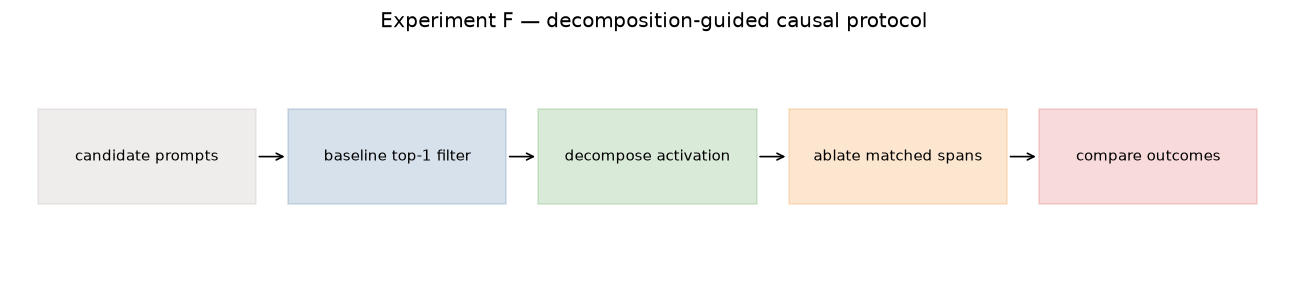

In [14]:
# NBVAL_IGNORE_OUTPUT
fig, ax = plt.subplots(figsize=(11, 2.5), dpi=120)
ax.axis("off")
labels = ["candidate prompts", "baseline top-1 filter", "decompose activation", "ablate matched spans", "compare outcomes"]
colors = ["#BAB0AC", "#4C78A8", "#59A14F", "#F28E2B", "#E15759"]
for index, (label, color) in enumerate(zip(labels, colors)):
    x = 0.02 + index * 0.195
    ax.add_patch(plt.Rectangle((x, 0.3), 0.17, 0.4, color=color, alpha=0.22))
    ax.text(x + 0.085, 0.5, label, ha="center", va="center", fontsize=9, wrap=True)
    if index < len(labels) - 1:
        ax.annotate("", xy=(x + 0.195, 0.5), xytext=(x + 0.17, 0.5), arrowprops={"arrowstyle": "->"})
ax.set(xlim=(0, 1), ylim=(0, 1))
ax.set_title("Experiment F — decomposition-guided causal protocol")
plt.tight_layout()
plt.show()

**Protocol caption.** Filtering is declared before intervention results are inspected. **Figure description:** five linked boxes trace candidate prompts through baseline filtering, decomposition, norm-matched span ablation, and outcome comparison. Every intervention acts only at one layer and the final prompt position; there is no layer-band clamp, country swap, or alpha sweep.

## Experiment F — causal relevance of decomposition-selected spans

**Question.** Does a selected-span intervention change a baseline-correct next-token prediction more than an equal-dimensional random-span intervention with exactly matched removed activation norm? For each nearby random candidate, both projection-removal scales are reduced to the smaller pairwise norm; full selected, active, and ranked-span ablations remain descriptive comparators. This establishes only causal relevance relative to the controls below—not J-space privilege over a matched non-J-space concept representation.

In [15]:
# NBVAL_IGNORE_OUTPUT
CAUSAL_LAYER = 6
CAUSAL_CANDIDATES = (
    ("The largest planet in the Solar System is", " Jupiter"), ("The red planet is", " Mars"),
    ("Earth's natural satellite is the", " Moon"), ("The star at the center of our Solar System is the", " Sun"),
    ("The largest ocean on Earth is the", " Pacific"), ("Water freezes at zero degrees", " Celsius"),
    ("The chemical symbol for gold is", " Au"), ("The chemical symbol for oxygen is", " O"),
    ("Plants release the gas called", " oxygen"), ("Humans breathe in", " oxygen"),
    ("The author of Hamlet was William", " Shakespeare"), ("Romeo and", " Juliet"),
    ("The first month of the year is", " January"), ("The last month of the year is", " December"),
    ("The day after Monday is", " Tuesday"), ("The day before Friday is", " Thursday"),
    ("There are seven days in a", " week"), ("There are twelve months in a", " year"),
    ("One hundred cents make one", " dollar"), ("Two plus two equals", " four"),
    ("Three plus three equals", " six"), ("The opposite of hot is", " cold"),
    ("The opposite of dark is", " light"), ("Fresh snow is usually", " white"),
    ("Grass is usually", " green"), ("A dog says", " woof"),
    ("A cat says", " meow"), ("A baby dog is called a", " puppy"),
    ("A shape with three sides is a", " triangle"), ("A shape with four equal sides is a", " square"),
    ("Brazil's official language is", " Portuguese"), ("The currency of the United States is the", " dollar"),
    ("The process plants use to turn light into energy is", " photosynthesis"), ("The organ that pumps blood is the", " heart"),
)

def orthonormal_basis(dictionary, token_ids):
    if len(token_ids) == 0:
        raise ValueError("a causal span must contain at least one atom")
    index = torch.as_tensor(token_ids, device=dictionary.device, dtype=torch.long)
    vectors = dictionary[index].float().T
    rank = int(torch.linalg.matrix_rank(vectors).item())
    if rank != vectors.shape[1]:
        raise ValueError(f"rank-deficient span: rank={rank}, atoms={vectors.shape[1]}")
    basis, _ = torch.linalg.qr(vectors, mode="reduced")
    return basis

def subspace_ablation_hook(basis, scale=1.0):
    def hook(activation, hook):
        edited = activation.clone()
        local_basis = basis.to(device=edited.device, dtype=edited.dtype)
        value = edited[:, -1, :]
        projection = (value @ local_basis) @ local_basis.T
        edited[:, -1, :] = value - scale * projection
        return edited
    return hook

def next_token_metrics(baseline_logits, edited_logits, target_id):
    baseline = baseline_logits.float()
    edited = edited_logits.float()
    baseline_prob = baseline.softmax(-1)
    edited_prob = edited.softmax(-1)
    baseline_log_prob = baseline.log_softmax(-1)
    edited_log_prob = edited.log_softmax(-1)
    return {
        "target_logit_change": float(edited[target_id] - baseline[target_id]),
        "target_probability_change": float(edited_prob[target_id] - baseline_prob[target_id]),
        "target_rank_change": int((edited > edited[target_id]).sum() - (baseline > baseline[target_id]).sum()),
        "top1_retained": int(edited.argmax().item() == target_id),
        "kl_from_baseline": float(torch.sum(baseline_prob * (baseline_log_prob - edited_log_prob))),
    }

def bootstrap_ci(values, seed, draws=1000):
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return (float("nan"), float("nan"))
    generator = np.random.default_rng(seed)
    means = generator.choice(values, size=(draws, values.size), replace=True).mean(axis=1)
    return tuple(np.quantile(means, [0.025, 0.975]))

# Model-free checks for the notebook-local projector helper.
synthetic_dictionary = torch.eye(4)
synthetic_basis = orthonormal_basis(synthetic_dictionary, [0, 2])
assert torch.allclose(synthetic_basis.T @ synthetic_basis, torch.eye(2), atol=1e-6)
synthetic_activation = torch.tensor([[[1.0, 2.0, 3.0, 4.0]]])
synthetic_edited = subspace_ablation_hook(synthetic_basis)(synthetic_activation, None)
assert synthetic_edited.shape == synthetic_activation.shape
assert synthetic_edited.dtype == synthetic_activation.dtype
assert torch.allclose(synthetic_edited[0, -1] @ synthetic_basis, torch.zeros(2), atol=1e-6)
try:
    orthonormal_basis(synthetic_dictionary, [])
except ValueError:
    pass
else:
    raise AssertionError("empty spans must be rejected")

In [16]:
# NBVAL_IGNORE_OUTPUT
causal_hook_name = f"blocks.{CAUSAL_LAYER}.hook_out"
causal_dictionary = lens.lens_vector_dictionary(model, CAUSAL_LAYER)
causal_rows = []
rejection_reasons = {"multi_token_target": 0, "baseline_not_top1": 0, "empty_support": 0, "rank_deficient": 0}
valid_trials = 0

for candidate_index, (prompt, target_text) in enumerate(CAUSAL_CANDIDATES):
    if MAX_CAUSAL_VALID_TRIALS is not None and valid_trials >= MAX_CAUSAL_VALID_TRIALS:
        break
    encoded_target = model.tokenizer.encode(target_text, add_special_tokens=False)
    if len(encoded_target) != 1:
        rejection_reasons["multi_token_target"] += 1
        continue
    target_id = encoded_target[0]
    tokens = model.to_tokens(prompt)
    baseline_output, cache = model.run_with_cache(tokens, names_filter=[causal_hook_name])
    baseline_logits = baseline_output[0, -1].detach()
    if baseline_logits.argmax().item() != target_id:
        rejection_reasons["baseline_not_top1"] += 1
        continue
    activation = cache[causal_hook_name][0, -1].detach()
    decomposition = lens.decompose(model, activation, layer=CAUSAL_LAYER, k=K)
    selected_ids = decomposition.selected_support.tolist()
    if not selected_ids:
        rejection_reasons["empty_support"] += 1
        continue
    try:
        selected_basis = orthonormal_basis(causal_dictionary, selected_ids)
    except ValueError:
        rejection_reasons["rank_deficient"] += 1
        continue
    selected_removed = (activation.float() @ selected_basis) @ selected_basis.T
    selected_removed_fraction = float(selected_removed.norm() / activation.float().norm())
    valid_trials += 1
    active_ids = decomposition.support.tolist()
    ranked = lens.readout(
        model, prompt, layers=[CAUSAL_LAYER], positions=[-1], top_k=len(selected_ids)
    ).lens_topk_indices[CAUSAL_LAYER][0].tolist()
    condition_bases = {
        "selected span": selected_basis,
        "ranked J-lens span": orthonormal_basis(causal_dictionary, ranked),
    }
    if active_ids:
        condition_bases["active span"] = orthonormal_basis(causal_dictionary, active_ids)
    for condition, basis in condition_bases.items():
        with model.hooks(fwd_hooks=[(causal_hook_name, subspace_ablation_hook(basis))]):
            edited_logits = model(tokens)[0, -1].detach()
        metrics = next_token_metrics(baseline_logits, edited_logits, target_id)
        removed = (activation.float() @ basis) @ basis.T
        metrics.update({
            "trial": valid_trials - 1, "condition": condition,
            "removed_norm_fraction": float(removed.norm() / activation.float().norm()),
        })
        causal_rows.append(metrics)
    excluded = set(selected_ids)
    generator = torch.Generator(device="cpu").manual_seed(SEED + candidate_index)
    allowed = torch.tensor([index for index in range(model.cfg.d_vocab) if index not in excluded])
    random_candidates = []
    for _ in range(NUM_RANDOM_CANDIDATE_SPANS):
        random_ids = allowed[torch.randperm(len(allowed), generator=generator)[:len(selected_ids)]].tolist()
        random_basis = orthonormal_basis(causal_dictionary, random_ids)
        random_removed = (activation.float() @ random_basis) @ random_basis.T
        removed_fraction = float(random_removed.norm() / activation.float().norm())
        random_candidates.append((abs(removed_fraction - selected_removed_fraction), removed_fraction, random_basis))
    random_candidates.sort(key=lambda item: item[0])
    matched_selected_metrics = []
    random_metrics = []
    for match_gap, removed_fraction, random_basis in random_candidates[:NUM_RANDOM_SPANS]:
        target_removed_fraction = min(selected_removed_fraction, removed_fraction)
        selected_scale = target_removed_fraction / selected_removed_fraction
        random_scale = target_removed_fraction / removed_fraction
        with model.hooks(fwd_hooks=[(causal_hook_name, subspace_ablation_hook(selected_basis, selected_scale))]):
            matched_selected_logits = model(tokens)[0, -1].detach()
        with model.hooks(fwd_hooks=[(causal_hook_name, subspace_ablation_hook(random_basis, random_scale))]):
            random_logits = model(tokens)[0, -1].detach()
        matched_selected_metric = next_token_metrics(baseline_logits, matched_selected_logits, target_id)
        random_metric = next_token_metrics(baseline_logits, random_logits, target_id)
        for metric, scale in [(matched_selected_metric, selected_scale), (random_metric, random_scale)]:
            metric["removed_norm_fraction"] = target_removed_fraction
            metric["ablation_scale"] = scale
            metric["candidate_norm_gap"] = match_gap
        matched_selected_metrics.append(matched_selected_metric)
        random_metrics.append(random_metric)
    matched_selected_row = {key: float(np.mean([item[key] for item in matched_selected_metrics])) for key in matched_selected_metrics[0]}
    matched_selected_row.update({"trial": valid_trials - 1, "condition": "norm-matched selected span mean"})
    causal_rows.append(matched_selected_row)
    random_row = {key: float(np.mean([item[key] for item in random_metrics])) for key in random_metrics[0]}
    random_row.update({"trial": valid_trials - 1, "condition": "norm-matched random span mean"})
    causal_rows.append(random_row)

print(f"candidates={len(CAUSAL_CANDIDATES)} valid={valid_trials} rejected={sum(rejection_reasons.values())}")
print("rejection reasons:", rejection_reasons)
if valid_trials < 20:
    print("UNDERPOWERED: fewer than 20 baseline-valid trials; interpret Experiment F as exploratory.")
matched_rows = [row for row in causal_rows if row["condition"] == "norm-matched random span mean"]
matched_selected_rows = [row for row in causal_rows if row["condition"] == "norm-matched selected span mean"]
selected_rows_for_report = [row for row in causal_rows if row["condition"] == "selected span"]
print(f"mean selected removed-norm fraction={np.mean([row['removed_norm_fraction'] for row in selected_rows_for_report]):.4f}")
print(f"mean exact-matched removed-norm fraction={np.mean([row['removed_norm_fraction'] for row in matched_rows]):.4f}")
print(f"mean candidate norm gap before scaling={np.mean([row['candidate_norm_gap'] for row in matched_rows]):.4f}")
for condition in sorted({row["condition"] for row in causal_rows}):
    changes = [row["target_logit_change"] for row in causal_rows if row["condition"] == condition]
    lower, upper = bootstrap_ci(changes, SEED)
    print(f"{condition:20s} mean logit change={np.mean(changes): .4f} 95% bootstrap CI=({lower:.4f}, {upper:.4f})")

candidates=34 valid=7 rejected=27
rejection reasons: {'multi_token_target': 3, 'baseline_not_top1': 24, 'empty_support': 0, 'rank_deficient': 0}
UNDERPOWERED: fewer than 20 baseline-valid trials; interpret Experiment F as exploratory.
mean selected removed-norm fraction=0.1377
mean exact-matched removed-norm fraction=0.1092
mean candidate norm gap before scaling=0.0290
active span          mean logit change=-8.7006 95% bootstrap CI=(-12.4678, -5.2819)
norm-matched random span mean mean logit change=-2.4583 95% bootstrap CI=(-3.8764, -1.0798)
norm-matched selected span mean mean logit change=-7.3397 95% bootstrap CI=(-10.5832, -4.1777)
ranked J-lens span   mean logit change=-5.3390 95% bootstrap CI=(-8.2328, -2.7799)
selected span        mean logit change=-8.6588 95% bootstrap CI=(-12.3520, -5.2828)


matched selected minus random mean=-4.8814 95% bootstrap CI=(-8.2973, -2.0723)


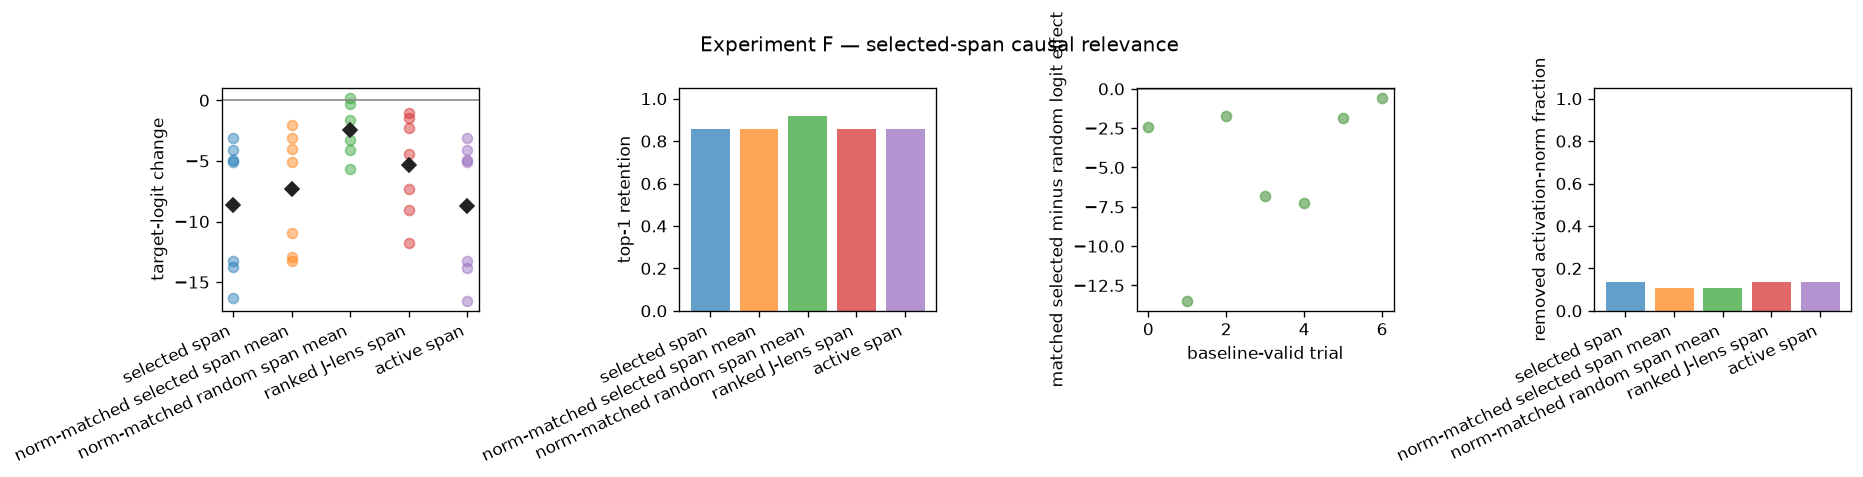

In [17]:
# NBVAL_IGNORE_OUTPUT
conditions = ["selected span", "norm-matched selected span mean", "norm-matched random span mean", "ranked J-lens span", "active span"]
conditions = [condition for condition in conditions if any(row["condition"] == condition for row in causal_rows)]
fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.8), dpi=120)
for index, condition in enumerate(conditions):
    rows = [row for row in causal_rows if row["condition"] == condition]
    logit_changes = [row["target_logit_change"] for row in rows]
    axes[0].scatter(np.full(len(rows), index), logit_changes, alpha=0.45)
    axes[0].plot(index, np.mean(logit_changes), marker="D", color="#222222")
    axes[1].bar(index, np.mean([row["top1_retained"] for row in rows]), alpha=0.7)
    axes[3].bar(index, np.mean([row["removed_norm_fraction"] for row in rows]), alpha=0.7)
axes[0].axhline(0, color="#888888", linewidth=1)
axes[0].set(ylabel="target-logit change")
axes[1].set(ylabel="top-1 retention", ylim=(0, 1.05))
selected_by_trial = {row["trial"]: row["target_logit_change"] for row in causal_rows if row["condition"] == "norm-matched selected span mean"}
random_by_trial = {row["trial"]: row["target_logit_change"] for row in causal_rows if row["condition"] == "norm-matched random span mean"}
common_trials = sorted(selected_by_trial.keys() & random_by_trial.keys())
differences = [selected_by_trial[trial] - random_by_trial[trial] for trial in common_trials]
difference_lower, difference_upper = bootstrap_ci(differences, SEED)
print(f"matched selected minus random mean={np.mean(differences):.4f} 95% bootstrap CI=({difference_lower:.4f}, {difference_upper:.4f})")
axes[2].scatter(common_trials, differences, alpha=0.65, color="#59A14F")
axes[2].axhline(0, color="#888888", linewidth=1)
axes[2].set(xlabel="baseline-valid trial", ylabel="matched selected minus random logit effect")
axes[3].set(ylabel="removed activation-norm fraction", ylim=(0, 1.05))
for axis in (axes[0], axes[1], axes[3]):
    axis.set_xticks(range(len(conditions)), conditions, rotation=25, ha="right")
fig.suptitle("Experiment F — selected-span causal relevance")
plt.tight_layout()
plt.show()

**Experiment F caption.** The saved full-tier run evaluates every baseline-valid non-country candidate. Sixteen nearby controls are selected from 128 equal-dimensional random candidates per trial, then each selected/random pair is partially ablated to the smaller projected norm, making removed activation norm exactly equal. The generated output and result summary below report the canonical trial count, paired effect, and uncertainty interval. **Figure description:** four panels compare target-logit change, top-1 retention, paired effects, and removed activation-norm fractions. This remains an underpowered within-J-space comparison, not a matched non-J-space concept control, and does not repeat the existing country-swap experiment.

## Takeaways and cleanup

Experiments A–E separate local sparse coordinates, corpus projection fractions, random-control occupancy, ranked readouts, and solver behavior. Experiment F asks only whether decomposition-selected spans are causally consequential relative to explicit J-space controls. Refer to the [Jacobian Lens demo](https://github.com/TransformerLensOrg/TransformerLens/blob/dev/demos/Jacobian_Lens_Demo.ipynb) for coordinate swaps, steering, and fitting, and to the [Jacobian Lens documentation](https://transformerlensorg.github.io/TransformerLens/content/jacobian_lens_fitting.html) for the full API contracts.

In [18]:
# NBVAL_IGNORE_OUTPUT
variance_medians = [variance_profile.median[layer] for layer in variance_profile.layers]
variance_pooled = [variance_profile.pooled[layer] for layer in variance_profile.layers]
occupancies = [row["occupancy"] for row in occupancy_trials]
jacobian_overlaps = [row["jacobian_jaccard"] for row in overlap_trials]
logit_overlaps = [row["logit_jaccard"] for row in overlap_trials]
nnomp_rows = [row for row in algorithm_trials if row["algorithm"] == ALGORITHMS[0]]
gradient_rows = [row for row in algorithm_trials if row["algorithm"] == ALGORITHMS[1]]
selected_rows = [row for row in causal_rows if row["condition"] == "selected span"]
matched_rows = [row for row in causal_rows if row["condition"] == "norm-matched random span mean"]
paired_effects = [
    selected_by_trial[trial] - random_by_trial[trial] for trial in common_trials
]
summary_rows = [
    ("A", "Local sparse coordinates", f"{len(coordinate_results)} prompts; active and selected support reported"),
    ("B", "Absolute selected-span variance", f"median {min(variance_medians):.2%}–{max(variance_medians):.2%}; pooled {min(variance_pooled):.2%}–{max(variance_pooled):.2%}"),
    ("C", "Control-calibrated occupancy", f"range {min(occupancies)}–{max(occupancies)} over {len(occupancies)} prompt/layer trials"),
    ("D", "Sparse/ranked support overlap", f"global median J-lens {np.nanmedian(jacobian_overlaps):.3f}; logit lens {np.nanmedian(logit_overlaps):.3f}"),
    ("E", "Solver trade-off", f"median synchronized runtime NNOMP {np.median([row['runtime_ms'] for row in nnomp_rows]):.1f} ms; gradient pursuit {np.median([row['runtime_ms'] for row in gradient_rows]):.1f} ms"),
    ("F", "Selected-span causal relevance", f"{valid_trials} baseline-valid trials; matched selected-minus-random mean {np.mean(paired_effects):.3f}; exact paired removed norm {np.mean([row['removed_norm_fraction'] for row in matched_rows]):.3f}"),
]
summary = ["## Result summary", "", "| Experiment | Estimand | Saved full-tier result |", "|---|---|---|"]
summary.extend(f"| {label} | {estimand} | {result} |" for label, estimand, result in summary_rows)
summary.extend(["", "Experiment F remains underpowered when fewer than 20 baseline-valid trials survive filtering; its within-J-space contrast does not establish J-space privilege over a non-J-space concept representation."])
display(Markdown("\n".join(summary)))

## Result summary

| Experiment | Estimand | Saved full-tier result |
|---|---|---|
| A | Local sparse coordinates | 4 prompts; active and selected support reported |
| B | Absolute selected-span variance | median 1.94%–2.80%; pooled 2.11%–4.85% |
| C | Control-calibrated occupancy | range 1–1 over 8 prompt/layer trials |
| D | Sparse/ranked support overlap | global median J-lens 0.094; logit lens 0.069 |
| E | Solver trade-off | median synchronized runtime NNOMP 104.8 ms; gradient pursuit 11.5 ms |
| F | Selected-span causal relevance | 7 baseline-valid trials; matched selected-minus-random mean -4.881; exact paired removed norm 0.109 |

Experiment F remains underpowered when fewer than 20 baseline-valid trials survive filtering; its within-J-space contrast does not establish J-space privilege over a non-J-space concept representation.

In [19]:
lens.clear_device_cache()
for name in ["cache", "causal_dictionary", "dictionary"]:
    globals().pop(name, None)
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Released cached lens dictionaries and temporary activation caches.")

Released cached lens dictionaries and temporary activation caches.
